In [1]:
# =========================
# importing libraries and setting up the environment for training Neural Networks
# =========================

# Standard library
from pathlib import Path
import copy
import os

# Third-party libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# Torchvision models
from torchvision import models
from torchvision.models import ViT_B_16_Weights, vit_b_16


In [2]:
# =========================
# hyperparameters
# =========================

num_epochs = 40
batch_size = 64
learning_rate = 0.001
model_name = "finetuned_vit"  # Name for saving model weights and results

In [ ]:
# =========================
# CIFAR-10 Transforms (for CNN)
# =========================

# Mean pixel values for CIFAR-10 dataset
# One value for each RGB channel: [Red, Green, Blue]

mean = np.array([0.485, 0.456, 0.406])

# Standard deviation of pixel values for ImageNet
std = np.array([0.229, 0.224, 0.225])

# Create image preprocessing pipeline
transform = transforms.Compose([

    # Resize CIFAR-10 images from 32x32 to 224x224
    # VGG16 expects larger input images
    transforms.Resize((224, 224)),

    # Convert PIL image or NumPy image to PyTorch tensor
    # Pixel range changes from [0,255] to [0,1]
    transforms.ToTensor(),

    # Normalize tensor using ImageNet statistics
    # output = (input - mean) / std
    transforms.Normalize(mean, std)
])

# =========================
# Datasets
# =========================

# Load CIFAR-10 training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

# Load CIFAR-10 test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# =========================
# DataLoaders
# =========================

# DataLoader for training data
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

# DataLoader for testing data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# =========================
# Classes
# =========================

classes = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

100%|██████████| 170M/170M [00:01<00:00, 95.3MB/s] 


In [ ]:
# =========================
# model building-Simple CNN for CIFAR-10
# =========================

class ViT_CIFAR10(nn.Module):
    """
    Vision Transformer (ViT-B/16) fine-tuned for CIFAR-10.

    Strategy:
    - Load pretrained ViT (ImageNet-1K)
    - Replace classification head for 10 classes
    - Freeze most encoder layers
    - Fine-tune:
        1. Last transformer block
        2. Classification head
        
    """

    def __init__(self, num_classes=10):
        super(ViT_CIFAR10, self).__init__()

        # Load pretrained ViT
        self.model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.IMAGENET1K_V1
        )

        # -----------------------------
        # STEP 1: Freeze all parameters
        # -----------------------------
        for param in self.model.parameters():
            param.requires_grad = False

        # -----------------------------
        # STEP 2: Replace classifier head
        # -----------------------------
        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Linear(in_features, num_classes)

        # -----------------------------
        # STEP 3: Unfreeze classifier head
        # -----------------------------
        for param in self.model.heads.parameters():
            param.requires_grad = True

        # -----------------------------
        # STEP 4: Unfreeze last transformer block
        # -----------------------------
        # ViT encoder blocks
        last_block = self.model.encoder.layers[-1]

        for param in last_block.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)


# =========================
# Instantiate model
# =========================
model = ViT_CIFAR10(num_classes=10)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 214MB/s]  


In [5]:
# ===================================
# Training Setup
# ===================================

# Define loss function for multi-class classification
# CrossEntropyLoss combines LogSoftmax + Negative Log Likelihood Loss
criterion = nn.CrossEntropyLoss()

# Define optimizer
# Adam adapts learning rates for each parameter during training
# Only parameters with requires_grad=True will be updated
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate
)

# Select device:
# Use GPU (CUDA) if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move model parameters to selected device
model.to(device)

# Display which device is being used
print(f"Using device: {device}")

Using device: cuda


In [6]:
# =========================
# Model evaluation function
# ========================= 

def model_evel(model, criterion, data_loader):
    """
    Evaluate the model on the given data loader and return accuracy and average loss.

    Args:
        model: The PyTorch model to evaluate.
        criterion: The loss function used to calculate error.
        data_loader: DataLoader containing evaluation dataset.

    Returns:
        tuple: (accuracy_percentage, average_loss)
    """

    # Set model to evaluation mode (disables dropout, batch norm updates, etc.)
    model.eval()

    # Variables to track correct predictions, total samples, and total loss
    correct = 0
    total = 0
    total_loss = 0

    # Disable gradient calculation for faster inference and lower memory usage
    with torch.no_grad():

        # Loop through batches of images and labels
        for images, labels in data_loader:

            # Move data to selected device (CPU/GPU)
            images, labels = images.to(device), labels.to(device)

            # Forward pass: get model predictions
            outputs = model(images)

            # Compute batch loss
            loss = criterion(outputs, labels)

            # Add batch loss to running total
            total_loss += loss.item()

            # Get predicted class index with highest score
            _, predicted = torch.max(outputs, 1)

            # Update total number of samples
            total += labels.size(0)

            # Count how many predictions are correct
            correct += (predicted == labels).sum().item()

    # Return accuracy (%) and average loss across all batches
    return 100 * correct / total, total_loss / len(data_loader)

In [7]:
# =========================
# Training loop
# =========================

def train(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    num_epochs=1,
    save_path=None
):
    """
    Train a PyTorch model with periodic evaluation and best-model checkpointing.

    This function:
    - Trains the model using the provided training dataloader
    - Evaluates performance on the test set after each epoch
    - Tracks loss and accuracy for both training and testing
    - Saves the best-performing model (based on test accuracy)

    Args:
        model (torch.nn.Module): Neural network to train
        train_loader (DataLoader): Training dataset loader
        test_loader (DataLoader): Test/validation dataset loader
        criterion (torch.nn.Module): Loss function (e.g., CrossEntropyLoss)
        optimizer (torch.optim.Optimizer): Optimizer (e.g., Adam, SGD)
        device (torch.device): CPU or GPU device
        num_epochs (int): Number of training epochs
        save_path (str or None): Path to save best model weights (.pth file).
                                 If None, model is not saved.

    Returns:
        tuple:
            - model (torch.nn.Module): Model loaded with best weights
            - train_losses_history (list): Training loss per epoch
            - test_losses_history (list): Test loss per epoch
            - train_accuracies_history (list): Training accuracy per epoch (%)
            - test_accuracies_history (list): Test accuracy per epoch (%)
    """

    # =========================
    # Metric storage
    # =========================
    train_losses_history = []
    test_losses_history = []
    train_accuracies_history = []
    test_accuracies_history = []

    # Track best performance
    best_test_acc = 0.0

    # Keep best model weights in memory
    best_model_state = copy.deepcopy(model.state_dict())

    # =========================
    # Prepare save directory
    # =========================
    if save_path is not None:
        # Ensure directory exists before saving model
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # =========================
    # Training loop (epochs)
    # =========================
    for epoch in range(num_epochs):

        # Reset epoch-level stats
        running_loss = 0.0
        running_correct = 0
        total_samples = 0

        # Set model to training mode (enables dropout, batchnorm updates, etc.)
        model.train()

        # =========================
        # Batch loop
        # =========================
        for images, labels in train_loader:

            # Move tensors to GPU/CPU
            images = images.to(device)
            labels = labels.to(device)

            # Reset gradients from previous step
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update model weights
            optimizer.step()

            # -------------------------
            # Statistics tracking
            # -------------------------

            # Accumulate loss (scaled by batch size)
            running_loss += loss.item() * labels.size(0)

            # Get predicted class labels
            _, predicted = torch.max(outputs, 1)

            # Count correct predictions
            running_correct += (predicted == labels).sum().item()

            # Track total samples seen
            total_samples += labels.size(0)

        # =========================
        # Evaluation phase
        # =========================
        test_acc, test_loss = model_evel(model, criterion, test_loader)

        # Compute epoch-level training metrics
        avg_train_loss = running_loss / total_samples
        train_acc = 100 * running_correct / total_samples

        # =========================
        # Save best model
        # =========================
        if test_acc > best_test_acc:
            best_test_acc = test_acc

            # Deep copy model weights to avoid mutation
            best_model_state = copy.deepcopy(model.state_dict())

            # Save to disk if path provided
            if save_path is not None:
                torch.save(best_model_state, save_path)

        # =========================
        # Logging
        # =========================
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {test_loss:.4f}, "
            f"Test Acc: {test_acc:.2f}%"
        )

        # Store history
        train_losses_history.append(avg_train_loss)
        test_losses_history.append(test_loss)
        train_accuracies_history.append(train_acc)
        test_accuracies_history.append(test_acc)

    # =========================
    # Load best model weights
    # =========================
    model.load_state_dict(best_model_state)

    return (
        model,
        train_losses_history,
        test_losses_history,
        train_accuracies_history,
        test_accuracies_history,
    )

In [ ]:
# Train the model and store returned results

# Returned values:
# 1. model                  -> trained model after all epochs
# 2. train_loss_history     -> list of average training loss per epoch
# 3. test_loss_history      -> list of average test loss per epoch
# 4. train_accuracy_history -> list of training accuracy per epoch
# 5. test_accuracy_history  -> list of test accuracy per epoch

save_dir = Path("../models") / model_name
save_dir.mkdir(parents=True, exist_ok=True)

model, train_loss_history, test_loss_history, train_accuracy_history, test_accuracy_history = train(
    model,           # CNN model to train
    train_loader,    # Training dataset loader
    test_loader,     # Test dataset loader
    criterion,       # Loss function
    optimizer,       # Optimizer for updating weights
    device,          # CPU or GPU device
    num_epochs=num_epochs,   # Number of training epochs
    save_path=save_dir / "best_model.pth"  # Path to save best model weights
)

Epoch [1/40] | Train Loss: 0.1743, Train Acc: 94.37% | Test Loss: 0.1328, Test Acc: 95.41%
Epoch [2/40] | Train Loss: 0.0908, Train Acc: 96.91% | Test Loss: 0.1252, Test Acc: 95.80%
Epoch [3/40] | Train Loss: 0.0584, Train Acc: 98.07% | Test Loss: 0.1461, Test Acc: 95.44%
Epoch [4/40] | Train Loss: 0.0388, Train Acc: 98.69% | Test Loss: 0.1447, Test Acc: 95.73%
Epoch [5/40] | Train Loss: 0.0276, Train Acc: 99.08% | Test Loss: 0.1578, Test Acc: 96.02%
Epoch [6/40] | Train Loss: 0.0238, Train Acc: 99.18% | Test Loss: 0.1833, Test Acc: 95.64%
Epoch [7/40] | Train Loss: 0.0199, Train Acc: 99.31% | Test Loss: 0.1602, Test Acc: 96.07%
Epoch [8/40] | Train Loss: 0.0160, Train Acc: 99.44% | Test Loss: 0.1919, Test Acc: 95.71%
Epoch [9/40] | Train Loss: 0.0157, Train Acc: 99.45% | Test Loss: 0.1962, Test Acc: 95.91%
Epoch [10/40] | Train Loss: 0.0142, Train Acc: 99.50% | Test Loss: 0.1989, Test Acc: 95.86%
Epoch [11/40] | Train Loss: 0.0093, Train Acc: 99.72% | Test Loss: 0.2082, Test Acc: 96.0

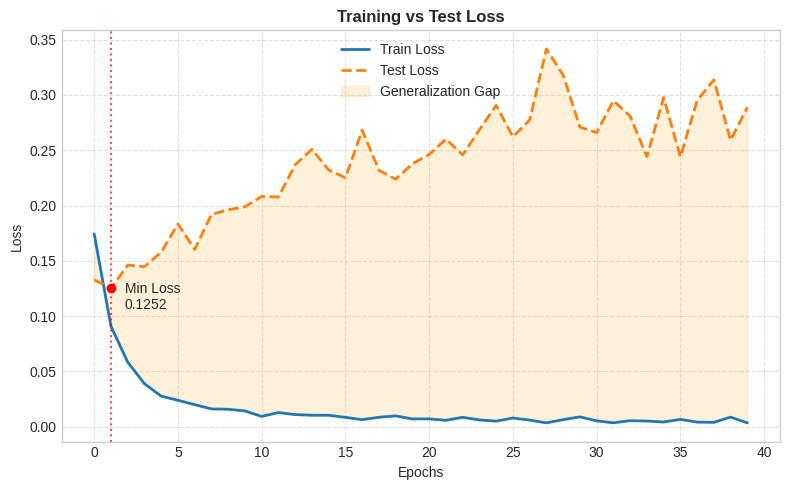


📊 TRAINING SUMMARY REPORT
Best epoch: 18
Train acc:  99.72%
Test acc:   96.13%



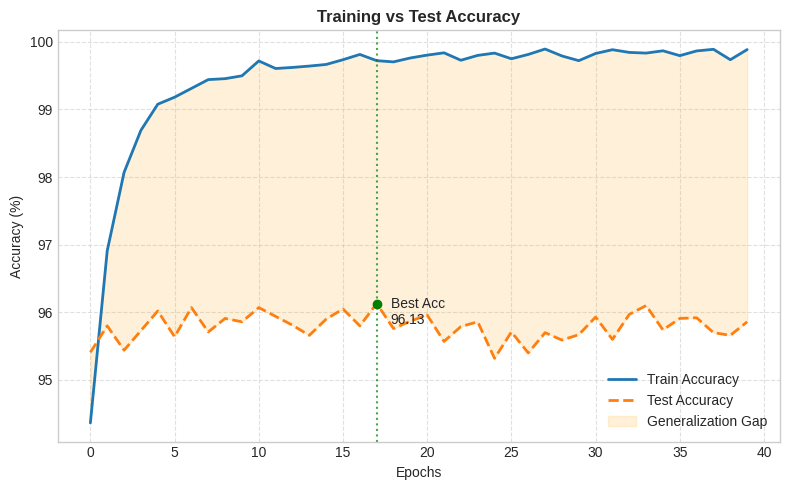

In [ ]:
# ----------------------
# Plotting configuration and utilities
# ----------------------

# Use a clean seaborn-based style for better readability of plots
plt.style.use("seaborn-v0_8-whitegrid")

# Directory where all plots will be saved
save_dir = Path("../results") / model_name
save_dir.mkdir(parents=True, exist_ok=True)

# Global plotting configuration
FIGSIZE = (8, 5)   # Figure size (width, height)
DPI = 300          # High resolution for saved figures


# ----------------------
# Plot Function
# ----------------------
def plot_curves(x1, x2, label1, label2, ylabel, title, filename, mode=None):
    """
    Plot training vs validation/test curves with analysis enhancements.

    Features:
    - Plots training vs test curves
    - Highlights best epoch (min loss or max accuracy)
    - Draws vertical line at best epoch
    - Marks best point on curve
    - Shows generalization gap (overfitting visualization)
    - Prints clean training summary (for accuracy mode only)
    - Saves figure to disk

    Parameters
    ----------
    x1 : list or array
        Training metric values (loss or accuracy)
    x2 : list or array
        Validation/Test metric values
    label1 : str
        Label for training curve
    label2 : str
        Label for test/validation curve
    ylabel : str
        Y-axis label (e.g., Loss, Accuracy)
    title : str
        Plot title
    filename : str
        Output filename for saved plot
    mode : str, optional
        Either "loss" or "accuracy" to control best-epoch logic
    """

    # Create a new figure for each plot
    plt.figure(figsize=FIGSIZE)

    # Generate epoch indices
    epochs = list(range(len(x1)))

    # ----------------------
    # Plot training and test curves
    # ----------------------
    plt.plot(epochs, x1, label=label1, linewidth=2)
    plt.plot(epochs, x2, label=label2, linewidth=2, linestyle="--")

    best_epoch = 0
    best_val = None

    # ----------------------
    # BEST EPOCH DETECTION
    # ----------------------
    if mode == "loss":
        # For loss → lower is better
        best_val = min(x2)
        best_epoch = x2.index(best_val)

        # Highlight best point
        plt.axvline(best_epoch, color="red", linestyle=":", alpha=0.7)
        plt.scatter(best_epoch, best_val, color="red", zorder=5)

        # Annotate best loss
        plt.annotate(
            f"Min Loss\n{best_val:.4f}",
            (best_epoch, best_val),
            textcoords="offset points",
            xytext=(10, -15)
        )

    elif mode == "accuracy":
        # For accuracy → higher is better
        best_val = max(x2)
        best_epoch = x2.index(best_val)  # +1 to convert from 0-based index to epoch number

        # Highlight best point
        plt.axvline(best_epoch, color="green", linestyle=":", alpha=0.7)
        plt.scatter(best_epoch, best_val, color="green", zorder=5)

        # Annotate best accuracy
        plt.annotate(
            f"Best Acc\n{best_val:.2f}",
            (best_epoch, best_val),
            textcoords="offset points",
            xytext=(10, -15)
        )

        # ----------------------
        # PRINT TRAINING SUMMARY
        # ----------------------
        print("\n" + "=" * 40)
        print("📊 TRAINING SUMMARY REPORT")
        print("=" * 40)
        print(f"Best epoch: {best_epoch+1}")
        print(f"Train acc:  {x1[best_epoch]:.2f}%")
        print(f"Test acc:   {x2[best_epoch]:.2f}%")
        print("=" * 40 + "\n")

    # ----------------------
    # GENERALIZATION GAP (OVERFITTING VISUALIZATION)
    # ----------------------
    plt.fill_between(
        epochs,
        x1,
        x2,
        color="orange",
        alpha=0.15,
        label="Generalization Gap"
    )

    # ----------------------
    # FORMATTING
    # ----------------------
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title, fontweight="bold")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Save figure to disk
    plt.savefig(save_dir / filename, dpi=DPI)

    # Display plot
    plt.show()


# ======================
# LOSS CURVE PLOT
# ======================

plot_curves(
    train_loss_history,
    test_loss_history,
    "Train Loss",
    "Test Loss",
    "Loss",
    "Training vs Test Loss",
    "loss_curve.png",
    mode="loss"
)


# ======================
# ACCURACY CURVE PLOT
# ======================

plot_curves(
    train_accuracy_history,
    test_accuracy_history,
    "Train Accuracy",
    "Test Accuracy",
    "Accuracy (%)",
    "Training vs Test Accuracy",
    "accuracy_curve.png",
    mode="accuracy"
)

Classification Report for Training Set:

              precision    recall  f1-score   support

       plane       1.00      1.00      1.00      5000
         car       1.00      1.00      1.00      5000
        bird       1.00      1.00      1.00      5000
         cat       1.00      1.00      1.00      5000
        deer       1.00      1.00      1.00      5000
         dog       1.00      1.00      1.00      5000
        frog       1.00      1.00      1.00      5000
       horse       1.00      1.00      1.00      5000
        ship       1.00      1.00      1.00      5000
       truck       1.00      1.00      1.00      5000

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000


Confusion Matrix for Training Set:



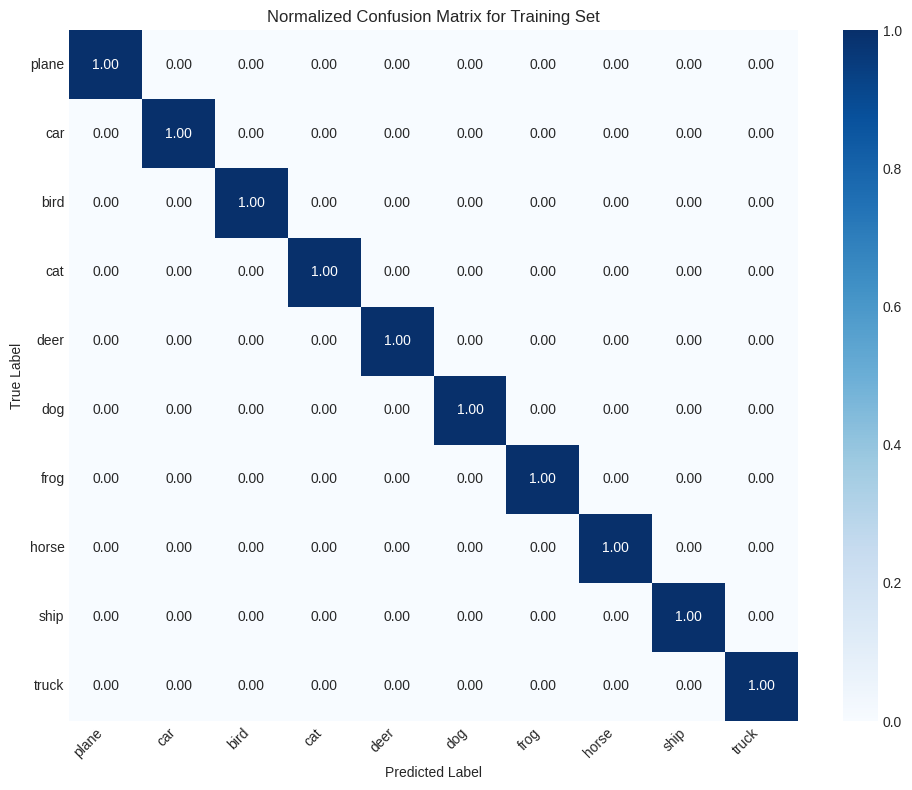

Classification Report for Test Set:

              precision    recall  f1-score   support

       plane       0.97      0.96      0.96      1000
         car       0.97      0.98      0.98      1000
        bird       0.97      0.95      0.96      1000
         cat       0.92      0.92      0.92      1000
        deer       0.95      0.97      0.96      1000
         dog       0.96      0.93      0.95      1000
        frog       0.98      0.97      0.97      1000
       horse       0.97      0.98      0.97      1000
        ship       0.97      0.97      0.97      1000
       truck       0.96      0.97      0.97      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000


Confusion Matrix for Test Set:



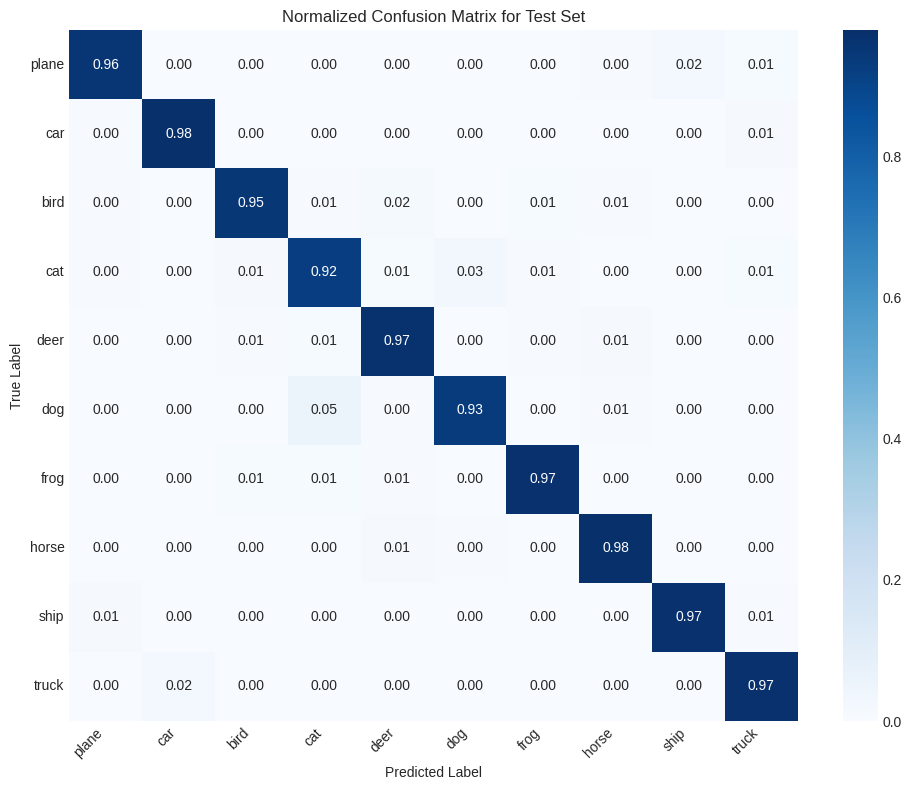

In [10]:
# =========================
# Classification Report and Confusion Matrix Function
# =========================

def classification_report_and_confusion_matrix(model, data_loader, device, classes=None):
    """
    Evaluate a trained classification model and compute performance metrics.

    This function runs inference on the dataset, collects predictions and true labels,
    and returns:
    - classification report
    - confusion matrix
    - raw predictions and labels
    """

    # Set model to evaluation mode (disables dropout, batch norm updates, etc.)
    model.eval()

    # Lists to store all predictions and ground-truth labels
    all_preds = []
    all_labels = []

    # Disable gradient computation for faster inference and lower memory usage
    with torch.no_grad():

        # Iterate over dataset batches
        for x_batch, y_batch in data_loader:

            # Move data to device (CPU/GPU)
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            outputs = model(x_batch)

            # Get predicted class index
            _, predicted = torch.max(outputs, 1)

            # Store predictions and labels (move back to CPU for numpy conversion)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # ----------------------
    # Handle class names
    # ----------------------
    if classes is not None:
        labels = list(range(len(classes)))  # Ensure consistent label order
        target_names = classes
    else:
        labels = None
        target_names = None

    # Generate classification report (precision, recall, f1-score)
    report = classification_report(
        all_labels,
        all_preds,
        labels=labels,
        target_names=target_names
    )

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=labels)

    return {
        "classification_report": report,
        "confusion_matrix": cm,
        "y_true": all_labels,
        "y_pred": all_preds
    }


def plot_confusion_matrix(
    cm,
    classes=None,
    normalize=False,
    title="Confusion Matrix",
    filename="confusion_matrix.png"
):
    """
    Plot a confusion matrix using a heatmap.

    Args:
        cm: Confusion matrix array (n_classes x n_classes)
        classes: List of class names
        normalize: If True, shows percentages instead of raw counts
        title: Plot title
        filename: Output image filename
    """

    # If class names not provided, use numeric labels
    if classes is None:
        classes = [str(i) for i in range(cm.shape[0])]

    # Normalize confusion matrix by row (true labels)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)  # Handle division by zero

    # Create figure
    plt.figure(figsize=(10, 8))

    # Draw heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    # Labels and formatting
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    # Improve layout
    plt.tight_layout()

    # Save plot
    plt.savefig(save_dir / filename, dpi=DPI)

    # Show plot
    plt.show()


# =========================
# TRAIN SET EVALUATION
# =========================

train_results = classification_report_and_confusion_matrix(
    model,
    train_loader,
    device,
    classes
)

print("Classification Report for Training Set:\n")
print(train_results["classification_report"])

print("\nConfusion Matrix for Training Set:\n")

plot_confusion_matrix(
    train_results["confusion_matrix"],
    classes=classes,
    normalize=True,
    title="Normalized Confusion Matrix for Training Set",
    filename="train_confusion_matrix.png"
)


# =========================
# TEST SET EVALUATION
# =========================

test_results = classification_report_and_confusion_matrix(
    model,
    test_loader,
    device,
    classes
)

print("Classification Report for Test Set:\n")
print(test_results["classification_report"])

print("\nConfusion Matrix for Test Set:\n")

plot_confusion_matrix(
    test_results["confusion_matrix"],
    classes=classes,
    normalize=True,
    title="Normalized Confusion Matrix for Test Set",
    filename="test_confusion_matrix.png"
)

In [ ]:
# -----------------------
# Sample Image Visualization
# -----------------------

def display_sample_images(
    data_loader,
    y_pred,
    class_names,
    num_samples=25,
    save_path=None,
    upscale_factor=4
):
    """
    Visualize a random subset of images from a DataLoader with
    their ground-truth and predicted labels.

    This function:
    - Retrieves a single batch from the provided data loader
    - Denormalizes CIFAR-10 images using standard mean/std values
    - Upscales images for better visualization
    - Randomly selects a subset of samples
    - Plots images in a grid with GT vs Pred labels
    - Optionally saves the resulting figure to disk

    Parameters
    ----------
    data_loader : torch.utils.data.DataLoader
        DataLoader providing image batches and labels.

    y_pred : array-like of shape (N,)
        Predicted class indices for the batch.

    class_names : list of str
        Mapping from class indices to human-readable labels.

    num_samples : int, optional (default=25)
        Number of images to display.

    save_path : str or pathlib.Path, optional
        If provided, saves the visualization image to this path.

    upscale_factor : int, optional (default=4)
        Factor by which to upscale images for better visibility.

    Returns
    -------
    None
        Displays a matplotlib figure and optionally saves it.
    """

    # Optional: increase global font size for better readability
    plt.rcParams.update({'font.size': 14})

    # CIFAR-10 normalization values
    mean = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
    std = np.array([0.2023, 0.1994, 0.2010], dtype=np.float32)

    # -----------------------
    # Get one batch
    # -----------------------
    images, y_true = next(iter(data_loader))

    # Tensor -> NumPy
    images = images.cpu().numpy()
    y_true = y_true.cpu().numpy()

    # (B, C, H, W) -> (B, H, W, C)
    images = np.transpose(images, (0, 2, 3, 1))

    # -----------------------
    # Undo normalization
    # -----------------------
    images = images * std + mean
    images = np.clip(images, 0, 1)

    # -----------------------
    # Upscale images
    # INTER_NEAREST 
    # -----------------------
    upscaled_images = []

    for img in images:
        h, w = img.shape[:2]

        img_up = cv2.resize(
            img,
            (w * upscale_factor, h * upscale_factor),
            interpolation=cv2.INTER_LINEAR
        )

        img_up = np.clip(img_up, 0, 1)
        upscaled_images.append(img_up)

    images = np.array(upscaled_images, dtype=np.float32)

    # -----------------------
    # Random samples
    # -----------------------
    total = len(images)
    num_samples = min(num_samples, total)

    indices = np.random.choice(total, num_samples, replace=False)

    # Grid layout
    cols = 5
    rows = int(np.ceil(num_samples / cols))

    plt.figure(figsize=(cols * 3, rows * 3))

    # -----------------------
    # Plot images
    # -----------------------
    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i + 1)

        plt.imshow(images[idx])

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        color = "green" if y_true[idx] == y_pred[idx] else "red"

        plt.title(
            f"GT: {true_label}\nPred: {pred_label}",
            fontsize=16,  # increased font size
            fontweight='bold',
            color=color
        )

        plt.axis("off")

    plt.tight_layout()

    # Save figure
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# -----------------------
# Save folder
# -----------------------
save_dir = Path("../results") / model_name
save_dir.mkdir(parents=True, exist_ok=True)

# -----------------------
# Run visualization
# -----------------------
display_sample_images(
    data_loader=test_loader,
    y_pred=test_results["y_pred"],
    class_names=classes,
    num_samples=25,
    save_path=save_dir / "sample_images.png",
    upscale_factor=4
)

NameError: name 'Path' is not defined